In [6]:
from math import *
import sys
import time

import numpy as np
from numpy.random import seed
from numpy.random import shuffle

import matplotlib.pyplot as plt

from scipy import signal
from scipy.stats import norm
from scipy.io.wavfile import read
from scipy.io import loadmat
from scipy.optimize import minimize_scalar

sys.path.append("..")
import Pylos_toolkit as PyT
import report_plotstyle

scaling = 10 ** (168./20)

# Script to investigate some common noise statistics
- (gaussian) spectrum
- Coherence
- Phase distribution

In [7]:
filename      = "../201650198.180131085932.wav"
time_trace    = read(filename)
sampling_rate = time_trace[0]
time_series   = time_trace[1]

print("Sampling rate:         ", sampling_rate, "Hz")
print("Length of time series: ", round(len(time_series)/sampling_rate/60), "minutes")

Sampling rate:          144000 Hz
Length of time series:  120 minutes


In [8]:
# From visual inspection, this timespan was relatively constant
trace_start = 2325.                   # [s]
trace_end   = trace_start + 10 * 60   # [s]

i_trace_start = int(trace_start * sampling_rate)
i_trace_end   = int(trace_end * sampling_rate)

t = np.arange((i_trace_end - i_trace_start),dtype=float)
t /= sampling_rate

y = np.array(time_series[i_trace_start : i_trace_end],dtype=float)

# Processing
# y *= scaling # Remove scaling, as we will rescale later
y -= np.mean(y) # Remove DC offset

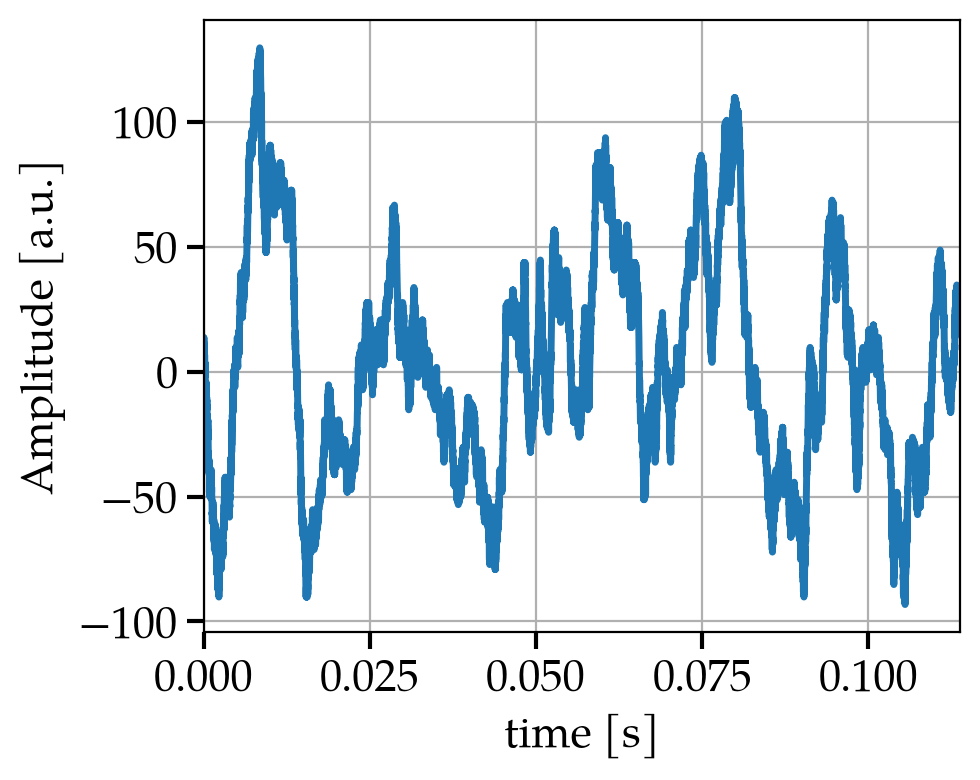

In [9]:
i_L = 4096*4
i0  = 0

t_plot = np.arange(i_L) / sampling_rate

plt.figure(figsize=(5,4))
plt.plot(t_plot, y[i0:i0+i_L])
plt.xlabel('time [s]')
plt.ylabel('Amplitude [a.u.]')
plt.xlim(0, t_plot[-1])
plt.tight_layout()
plt.grid()
plt.show()

# Generic PSD fit

In [10]:
freqs, PSD  = PyT.PSD_using_scipy(y, sampling_rate, nperseg=4096*2)
PSD_dB      = 10 * np.log10(PSD * scaling)   # of gewoon * 1e12?

/tmp/ipykernel_15051/2523584361.py:7: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim((min(freqs), max(freqs)))


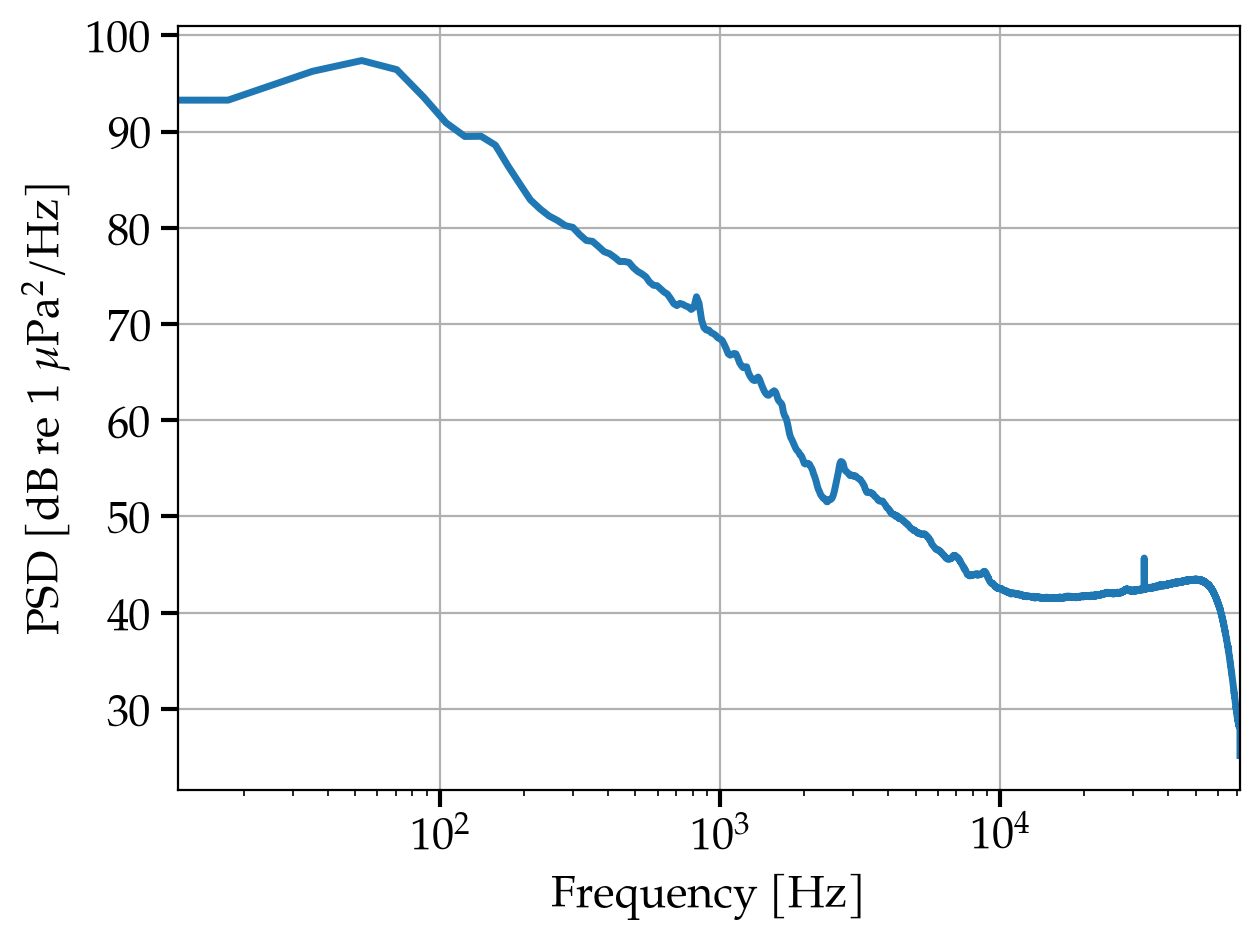

In [11]:
# plt.figure(figsize=(10,3))
plt.figure(figsize=(6.4,4.8))
plt.plot(freqs,PSD_dB)
plt.xscale('log')
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [dB re 1 $\mu$Pa$^2$/Hz]')
plt.xlim((min(freqs), max(freqs)))
plt.grid()
plt.tight_layout()

## Investigate amplitude spectrum
Is the noise gaussian?

In [12]:
def random_subtrace(times_series, length, sampling_rate=144e3):
    """
    Randomly select a subtrace of a given length from the time series.
    """
    start = np.random.randint(0, len(times_series) - length)
    if start + length > len(times_series):
        raise ValueError("The length of the subtrace exceeds the available data.")
    
    t = np.linspace(0, length / sampling_rate, length, endpoint=False)

    ts = times_series[start:start + length]
    ts = np.array(ts, dtype=float)

    return t, ts

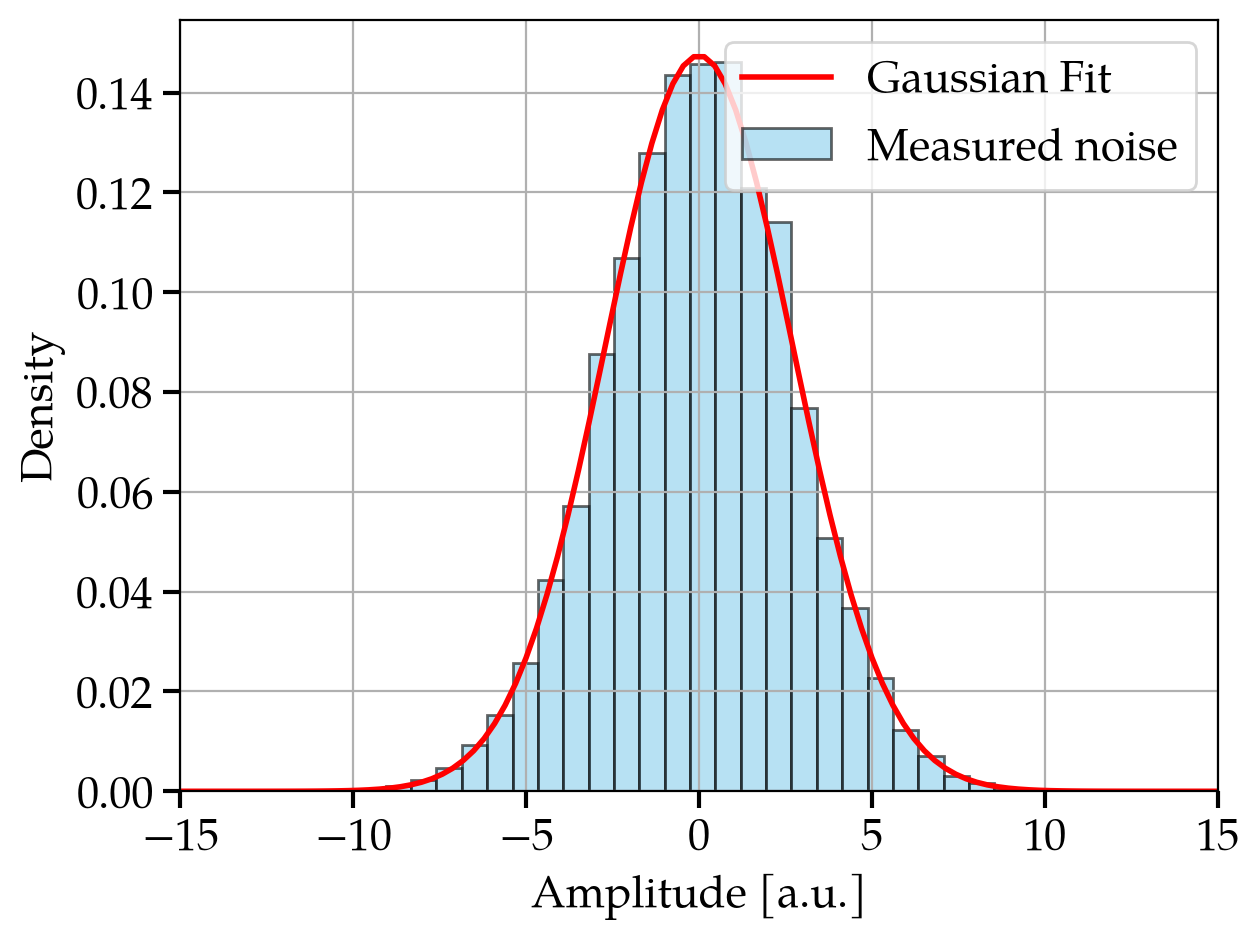

In [13]:
trace_start_hist = 2325.                 # [s] -> see notion: content/Noise in JPP
trace_end_hist   = trace_start_hist + 10 * 60  # [s]

i_trace_start_hist = int(trace_start_hist * sampling_rate)
i_trace_end_hist   = int(trace_end_hist * sampling_rate)

y_hist = np.array(time_series[i_trace_start_hist : i_trace_end_hist],dtype=float)

all_samples = y_hist  / np.sqrt(scaling) * 1000
hist_bins   = 50

# Fit a Gaussian to the combined data
all_samples -= np.mean(all_samples)
mu, std = norm.fit(all_samples)

# Make a histogram for plotting
counts, bin_edges = np.histogram(all_samples, bins=hist_bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

gauss_eval_x = np.linspace(-15, 15, 100)
gauss_fit = norm.pdf(gauss_eval_x, mu, std)

plt.figure()
plt.bar(bin_centers, counts, width=bin_edges[1]-bin_edges[0], color='skyblue', edgecolor='black', alpha=0.6, label='Measured noise')
plt.plot(gauss_eval_x, gauss_fit, 'r-', lw=2, label='Gaussian Fit')
plt.xlabel('Amplitude [a.u.]')
plt.ylabel('Density')
# plt.title(f'Mean Histogram of {num_samples} random subtraces of length 2e{int(np.log2(length))} with Gaussian Fit')
plt.legend()
plt.xlim(-15, 15)
plt.grid()
plt.tight_layout()
plt.show()

## Phase uniformity
Note that the following cell will crash if you use too long of a trace, as a rule of thumb I used:
```
trace_end-trace_start < 300
```

In [14]:
assert trace_end-trace_start < 5*60, "Too long of a trace"

phase = np.angle(np.fft.fft(y))[:]

# Make a histogram for plotting
counts, bin_edges = np.histogram(phase, bins=hist_bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.figure(figsize=(8, 5))
plt.bar(bin_centers, counts, width=bin_edges[1]-bin_edges[0], color='skyblue', edgecolor='black', alpha=0.6)
plt.xlabel('Amplitude')
plt.ylabel('Density')
plt.title(f'Phase Histogram of 10 second trace')
plt.grid()
plt.show()

AssertionError: Too long of a trace

## Autocorrelation of the noise
The autocorrelation settles around ~2500, so use 2048 points for further analysis

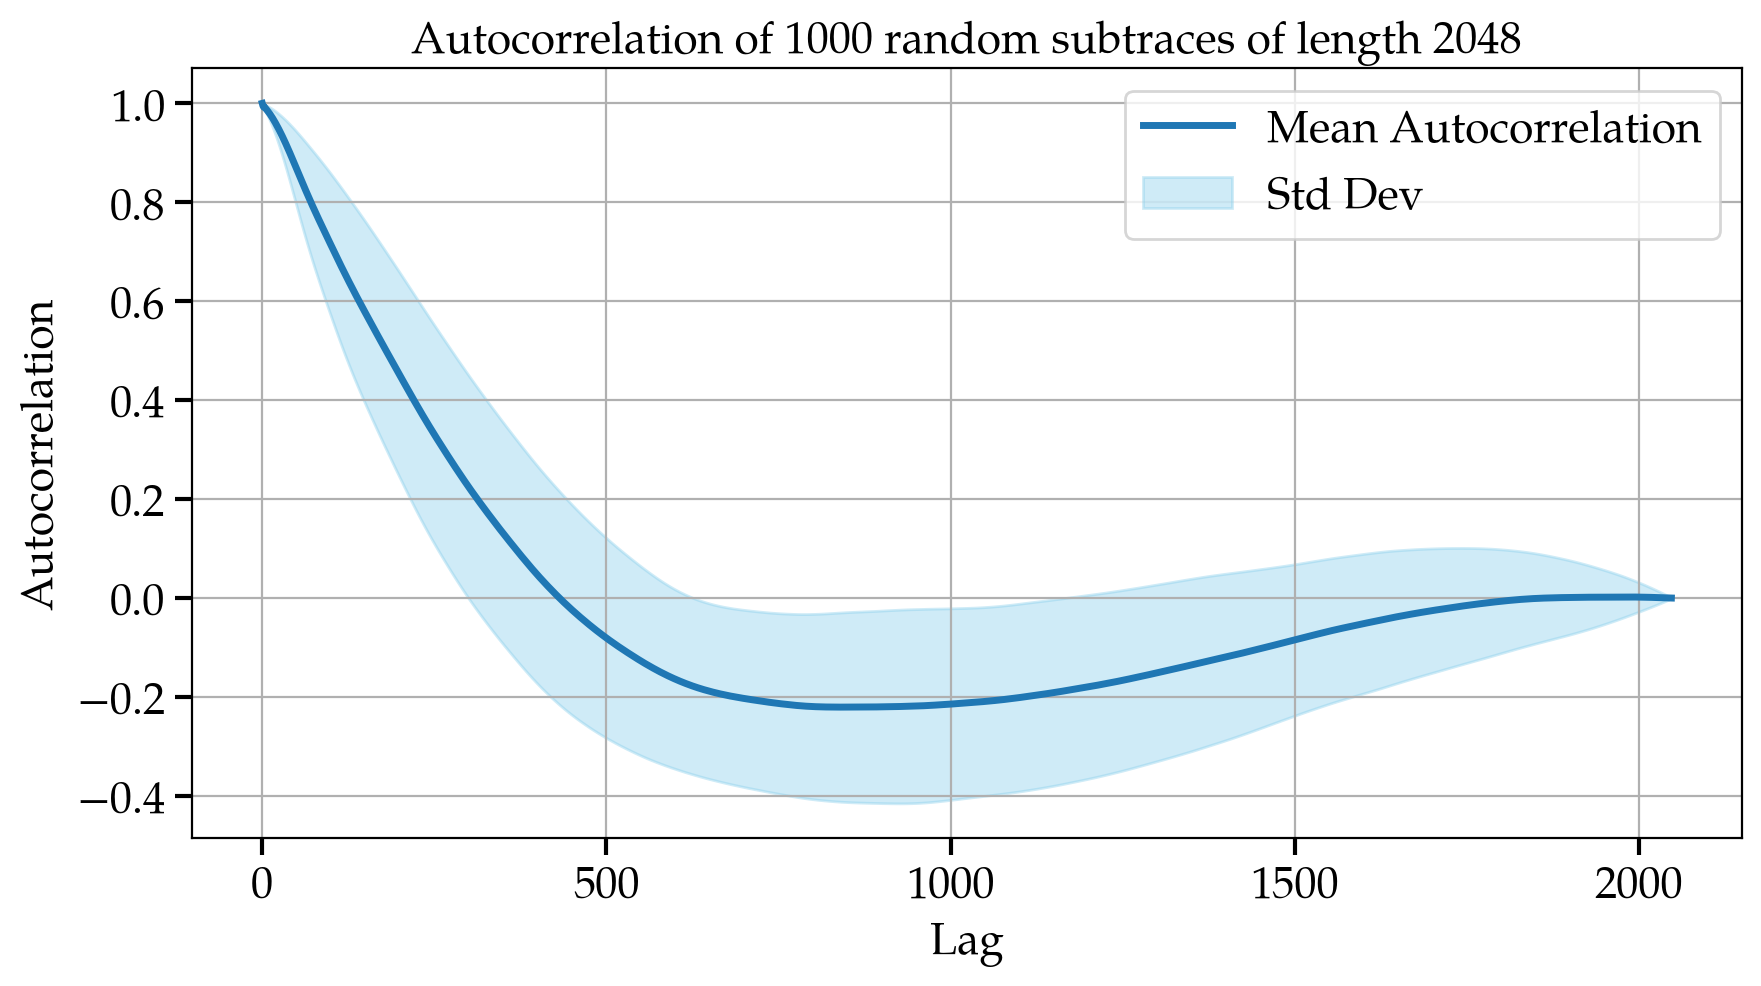

In [15]:
total_acorr = []
num_samples = 1000
length      = 2**11

for _ in range(num_samples):
  data = PyT.random_subtrace(y, length)[1]
  mean = np.mean(data)
  var = np.var(data)
  ndata = data - mean

  acorr = np.correlate(ndata, ndata, 'full')[len(ndata)-1:] 
  acorr = acorr / var / len(ndata)
  total_acorr.append(acorr)

total_acorr = np.array(total_acorr)
mean_acorr = np.mean(total_acorr, axis=0)
std_acorr = np.std(total_acorr, axis=0)
lags = np.arange(len(mean_acorr))

plt.figure(figsize=(10, 5))
plt.plot(lags, mean_acorr, label='Mean Autocorrelation')
plt.fill_between(lags, mean_acorr - std_acorr, mean_acorr + std_acorr, color='skyblue', alpha=0.4, label='Std Dev')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title(f'Autocorrelation of {num_samples} random subtraces of length {length}')
plt.grid()
plt.legend()
plt.show()